# mol3d_fullerene — Graph Diameter & Hasse Diameter Analysis

Two structural-complexity metrics per molecule, both **diameters** (longest shortest path), computed on 4 different graphs (test split only: 2,000 mol3d + 1,420 fullerene molecules, combined):

- **atom** — plain atom-bond graph diameter (`graph_diameter`)
- **ct6** — CT's 6-relation cell complex, **atom-restricted** Hasse diameter: longest shortest path between two *atoms*, but bond/ring cells can be used as shortcuts en route (`atom_hasse_diameter`)
- **cin** — CIN's message-passing graph, same atom-restricted construction (`cin_atom_hasse_diameter`)
- **cinpp** — CIN++'s message-passing graph, same atom-restricted construction (`cinpp_atom_hasse_diameter`)

Being atom-restricted, all three (`ct6`/`cin`/`cinpp`) are **guaranteed ≤ `atom`'s graph_diameter** (same endpoints, strictly more edges available to route through) — a ratio ≤ 1.0 always.

mol3d-side data reused from `../mol3d/dataset_per_molecule.npz` and `../mol3d/hasse_graph_cin_per_molecule.npz`, plus the local `mol3d_atom_hasse_test_only.npz`; fullerene-side from the local `fullerene_dataset_per_molecule.npz`, `fullerene_atom_hasse_per_molecule.npz`, and `fullerene_hasse_cin_per_molecule.npz`.

**SchNet** is included in the Overview/scatter sections below (`results_schnet.json`, non-tuned — no hp-tuned run exists), but is **excluded** from the "GNN vs. Other Architectures" section: SchNet doesn't message-pass over the bond/ring graph at all (continuous-filter convolutions over 3D distances instead), so it has no `ct6`/`cin`/`cinpp`-analogous graph type of its own to plot there.

In [16]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
pd.set_option('display.float_format', '{:.4f}'.format)

RESULTS_DIR = Path("results")

def load_result(path):
    with open(path) as f:
        return json.load(f)

def rerun_suffix(path):
    m = re.search(r"_(\d+)\.json$", path.name)
    return int(m.group(1)) if m else 0

by_group = {}
for path in sorted(RESULTS_DIR.glob("results_*_hptuned*.json")):
    d = load_result(path)
    if "feat_mode" in d:
        family = "CT"
        feature = d["feat_mode"]
    else:
        family = d["model"]
        feature = "-"
    key = (family, feature)
    suffix = rerun_suffix(path)
    if key not in by_group or suffix > by_group[key]["suffix"]:
        by_group[key] = {"path": path, "suffix": suffix, "data": d}

# SchNet isn't hp-tuned (no results_schnet_hptuned.json / best_hp_schnet.json), so it's
# not picked up by the glob above -- add its plain (non-tuned) result manually.
schnet_path = RESULTS_DIR / "results_schnet.json"
if schnet_path.exists():
    by_group[("SchNet", "-")] = {"path": schnet_path, "suffix": 0, "data": load_result(schnet_path)}

records = []
for (family, feature), entry in by_group.items():
    d = entry["data"]
    records.append({
        "file": entry["path"].name, "family": family, "feature": feature,
        "test_mae":  [r["test_mae"]  for r in d["runs"]],
        "num_params": d.get("num_params"),
    })

print(f"Using {len(records)} result files (newest rerun per group):")
for r in records:
    print(f"  {r['file']:28s} family={r['family']:5s} feature={r['feature']}")

Using 9 result files (newest rerun per group):
  results_GAT_hptuned.json     family=GAT   feature=-
  results_GCN_hptuned.json     family=GCN   feature=-
  results_GIN_hptuned.json     family=GIN   feature=-
  results_cin_hptuned.json     family=CIN   feature=-
  results_cinpp_hptuned.json   family=CINpp feature=-
  results_ct_coords_hptuned.json family=CT    feature=coords
  results_ct_full_hptuned.json family=CT    feature=full
  results_ct_simple_hptuned.json family=CT    feature=simple
  results_schnet.json          family=SchNet feature=-


In [17]:
def label(r):
    return r["family"] if r["feature"] == "-" else f'{r["family"]} ({r["feature"]})'

summary = pd.DataFrame([
    {"label": label(r), "family": r["family"], "feature": r["feature"],
     "mean_mae": np.mean(r["test_mae"])}
    for r in records
]).sort_values("mean_mae").reset_index(drop=True)

FAMILY_COLOR = {
    "CT":     "#2a78d6",
    "GCN":    "#1baf7a",
    "GAT":    "#eda100",
    "GIN":    "#008300",
    "CIN":    "#8172b2",
    "CINpp":  "#937860",
    "SchNet": "#64B5CD",
}
CT_FEATURE_ALPHA = {"full": 1.0, "simple": 0.65, "coords": 0.4}

def bar_color(row):
    base = FAMILY_COLOR[row["family"]]
    if row["family"] == "CT":
        alpha = CT_FEATURE_ALPHA.get(row["feature"], 0.8)
        rgb = np.array([int(base[i:i+2], 16) for i in (1, 3, 5)]) / 255
        white = np.array([1.0, 1.0, 1.0])
        rgb = alpha * rgb + (1 - alpha) * white
        return tuple(rgb)
    return base

def per_molecule_mae(d):
    err_by_key = {}
    for run in d["runs"]:
        for p in run["predictions"]:
            err_by_key.setdefault((p["source"], p["index"]), []).append(abs(p["pred"] - p["true"]))
    return {k: float(np.mean(v)) for k, v in err_by_key.items()}

err_maps = {}
for _, row in summary.iterrows():
    d = by_group[(row["family"], row["feature"])]["data"]
    err_maps[row["label"]] = per_molecule_mae(d)

model_labels = list(err_maps.keys())
n_models = len(model_labels)
MODEL_COLOR = {row["label"]: bar_color(row) for _, row in summary.iterrows()}

for lbl in model_labels:
    print(f"{lbl:14s} n_molecules={len(err_maps[lbl])}")

CINpp          n_molecules=3420
CIN            n_molecules=3420
CT (full)      n_molecules=3420
SchNet         n_molecules=3420
CT (simple)    n_molecules=3420
GAT            n_molecules=3420
GCN            n_molecules=3420
GIN            n_molecules=3420
CT (coords)    n_molecules=3420


In [18]:
PREFIXES = ('atom', 'ct6', 'cin', 'cinpp')

mol3d_atom_npz = np.load("../mol3d/dataset_per_molecule.npz")
mol3d_atom_pos = {int(i): k for k, i in enumerate(mol3d_atom_npz["index"])}
mol3d_atom_arr = mol3d_atom_npz["graph_diameter"].astype(float)

fullerene_atom_npz = np.load("fullerene_dataset_per_molecule.npz")
fullerene_atom_pos = {int(i): k for k, i in enumerate(fullerene_atom_npz["index"])}
fullerene_atom_arr = fullerene_atom_npz["graph_diameter"].astype(float)

mol3d_ct6_npz = np.load("mol3d_atom_hasse_test_only.npz")
mol3d_ct6_pos = {int(i): k for k, i in enumerate(mol3d_ct6_npz["index"])}
mol3d_ct6_arr = mol3d_ct6_npz["atom_hasse_diameter"].astype(float)

fullerene_ct6_npz = np.load("fullerene_atom_hasse_per_molecule.npz")
fullerene_ct6_pos = {int(i): k for k, i in enumerate(fullerene_ct6_npz["index"])}
fullerene_ct6_arr = fullerene_ct6_npz["atom_hasse_diameter"].astype(float)

mol3d_cin_npz = np.load("../mol3d/hasse_graph_cin_per_molecule.npz")
mol3d_cin_pos = {int(i): k for k, i in enumerate(mol3d_cin_npz["index"])}
mol3d_cin_arr = mol3d_cin_npz["cin_atom_hasse_diameter"].astype(float)
mol3d_cinpp_arr = mol3d_cin_npz["cinpp_atom_hasse_diameter"].astype(float)

fullerene_cin_npz = np.load("fullerene_hasse_cin_per_molecule.npz")
fullerene_cin_pos = {int(i): k for k, i in enumerate(fullerene_cin_npz["index"])}
fullerene_cin_arr = fullerene_cin_npz["cin_atom_hasse_diameter"].astype(float)
fullerene_cinpp_arr = fullerene_cin_npz["cinpp_atom_hasse_diameter"].astype(float)

POS = {
    "mol3d": {"atom": mol3d_atom_pos, "ct6": mol3d_ct6_pos, "cin": mol3d_cin_pos, "cinpp": mol3d_cin_pos},
    "fullerene": {"atom": fullerene_atom_pos, "ct6": fullerene_ct6_pos, "cin": fullerene_cin_pos, "cinpp": fullerene_cin_pos},
}
ARR = {
    "mol3d": {"atom": mol3d_atom_arr, "ct6": mol3d_ct6_arr, "cin": mol3d_cin_arr, "cinpp": mol3d_cinpp_arr},
    "fullerene": {"atom": fullerene_atom_arr, "ct6": fullerene_ct6_arr, "cin": fullerene_cin_arr, "cinpp": fullerene_cinpp_arr},
}

def get_diameter(source, index, prefix):
    pos = POS[source][prefix].get(index)
    return None if pos is None else float(ARR[source][prefix][pos])

# NOTE: mol3d's graph_diameter file spans the *full* ~3.9M-molecule Molecule3D
# corpus (not just our 10k sample), so its raw n/min/max/mean aren't
# meaningful here -- only report pool sizes, and see the Overview section
# below for stats properly restricted to the shared test population.
print(f"mol3d atom pool (full corpus): {len(mol3d_atom_pos):,}  |  test-only files: "
      f"ct6={len(mol3d_ct6_pos):,}  cin/cinpp={len(mol3d_cin_pos):,}")
print(f"fullerene: atom={len(fullerene_atom_pos):,}  ct6={len(fullerene_ct6_pos):,}  "
      f"cin/cinpp={len(fullerene_cin_pos):,}")

mol3d atom pool (full corpus): 3,899,526  |  test-only files: ct6=2,000  cin/cinpp=2,000
fullerene: atom=7,100  ct6=7,100  cin/cinpp=1,420


## Overview of Statistics

Combined (mol3d + fullerene) distribution of the diameter, for each of the 4 graphs. `ct6`/`cin`/`cinpp` files are test-only by construction per source; `atom`'s mol3d file covers the full 10k pool, so everything is restricted to each source's common test population before combining.

In [19]:
def common_ids(source):
    return sorted(set.intersection(*(set(POS[source][p]) for p in PREFIXES)))

mol3d_common = common_ids("mol3d")
fullerene_common = common_ids("fullerene")
print(f"mol3d common: {len(mol3d_common):,}  fullerene common: {len(fullerene_common):,}")

def diam_array(source, prefix, ids):
    pos, arr = POS[source][prefix], ARR[source][prefix]
    return np.array([arr[pos[i]] for i in ids if i in pos], dtype=float)

def combined_diam_array(prefix):
    return np.concatenate([
        diam_array("mol3d", prefix, mol3d_common),
        diam_array("fullerene", prefix, fullerene_common),
    ])

rows = []
for p in PREFIXES:
    arr = combined_diam_array(p)
    rows.append({
        "graph": p, "dataset_mean": arr.mean(), "dataset_std": arr.std(),
        "dataset_min": arr.min(), "dataset_max": arr.max(), "n_valid": len(arr),
    })

overview_df = pd.DataFrame(rows).set_index("graph")
display(overview_df.style.format(precision=2).background_gradient(subset=["dataset_mean"], cmap="RdYlGn_r"))

mol3d common: 2,000  fullerene common: 1,420


,dataset_mean,dataset_std,dataset_min,dataset_max,n_valid
graph,,,,,
atom,9.64,1.61,4.00,17.00,3420
ct6,7.81,2.10,4.00,17.00,3420
cin,8.60,1.99,4.00,17.00,3420
cinpp,8.56,1.96,4.00,17.00,3420


### Diameter distribution, by graph and source

Split by source since mol3d and fullerene occupy different regions of structural-complexity space.

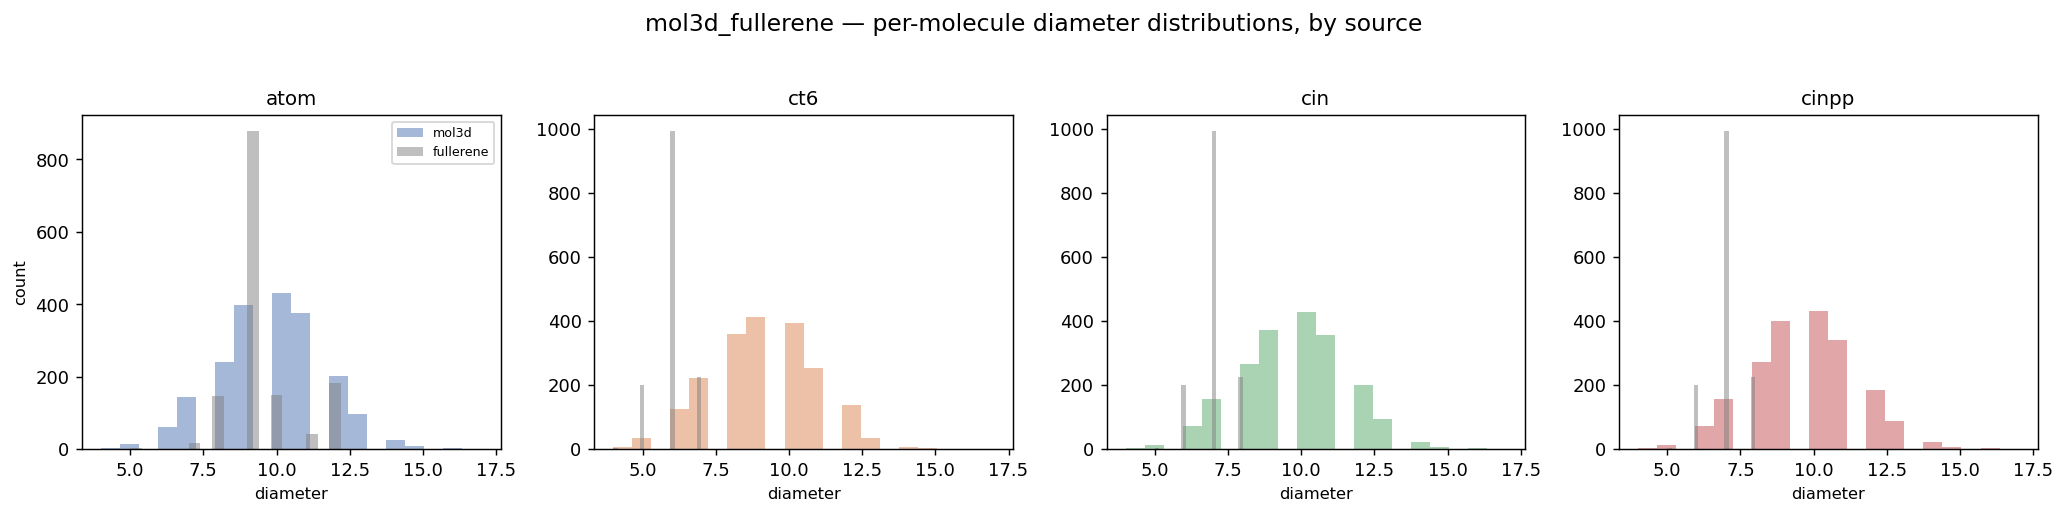

In [20]:
GRAPH_COLOR = {'atom': '#4C72B0', 'ct6': '#DD8452', 'cin': '#55A868', 'cinpp': '#C44E52'}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for col, p in enumerate(PREFIXES):
    ax = axes[col]
    ax.hist(diam_array("mol3d", p, mol3d_common), bins=20, alpha=0.5, label="mol3d", color=GRAPH_COLOR[p])
    ax.hist(diam_array("fullerene", p, fullerene_common), bins=20, alpha=0.5, label="fullerene", color="gray")
    ax.set_title(p, fontsize=11)
    ax.set_xlabel('diameter', fontsize=9)
    if col == 0:
        ax.set_ylabel('count', fontsize=9)
        ax.legend(fontsize=7)

plt.suptitle('mol3d_fullerene — per-molecule diameter distributions, by source', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## Diameter vs. Model Error — Every Model, Per Graph Type

For each of the 4 graphs, one row of scatter plots — every model shown side by side (mol3d + fullerene test molecules pooled), against that model's own per-molecule absolute test error. Dashed line = linear fit.

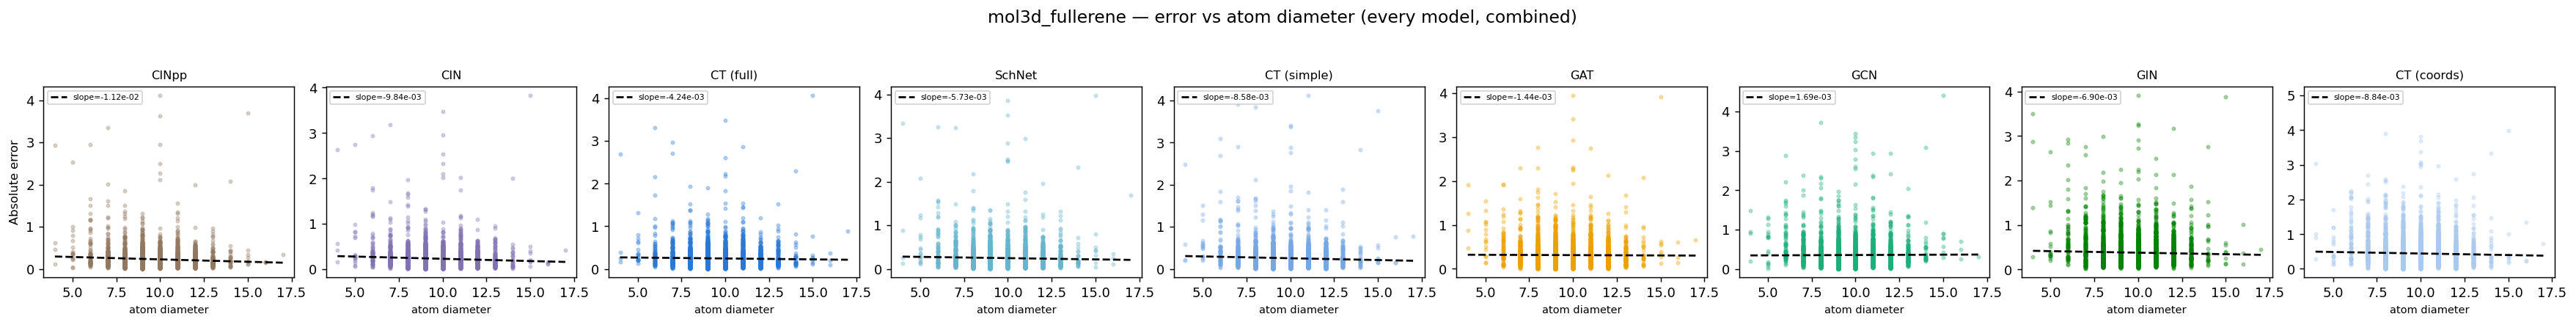

In [21]:
def plot_err_vs_diameter(prefix):
    fig, axes = plt.subplots(1, n_models, figsize=(3.0 * n_models, 3.2), squeeze=False)
    axes = axes[0]
    for col, lbl in enumerate(model_labels):
        ax = axes[col]
        color = MODEL_COLOR[lbl]
        err_by_key = err_maps[lbl]
        keys = [k for k in err_by_key if get_diameter(*k, prefix) is not None]
        x = np.array([get_diameter(*k, prefix) for k in keys])
        y = np.array([err_by_key[k] for k in keys])
        ax.scatter(x, y, color=color, alpha=0.3, s=6, rasterized=True)
        if len(x) >= 2 and np.ptp(x) > 0:
            coeffs = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 200)
            ax.plot(x_line, np.polyval(coeffs, x_line), color='black', linewidth=1.5,
                    linestyle='--', label=f'slope={coeffs[0]:.2e}')
            ax.legend(fontsize=6, loc='upper left')
        ax.set_title(lbl, fontsize=9)
        if col == 0:
            ax.set_ylabel('Absolute error', fontsize=9)
        ax.set_xlabel(f'{prefix} diameter', fontsize=8)
    plt.suptitle(f'mol3d_fullerene — error vs {prefix} diameter (every model, combined)',
                 fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

plot_err_vs_diameter('atom')

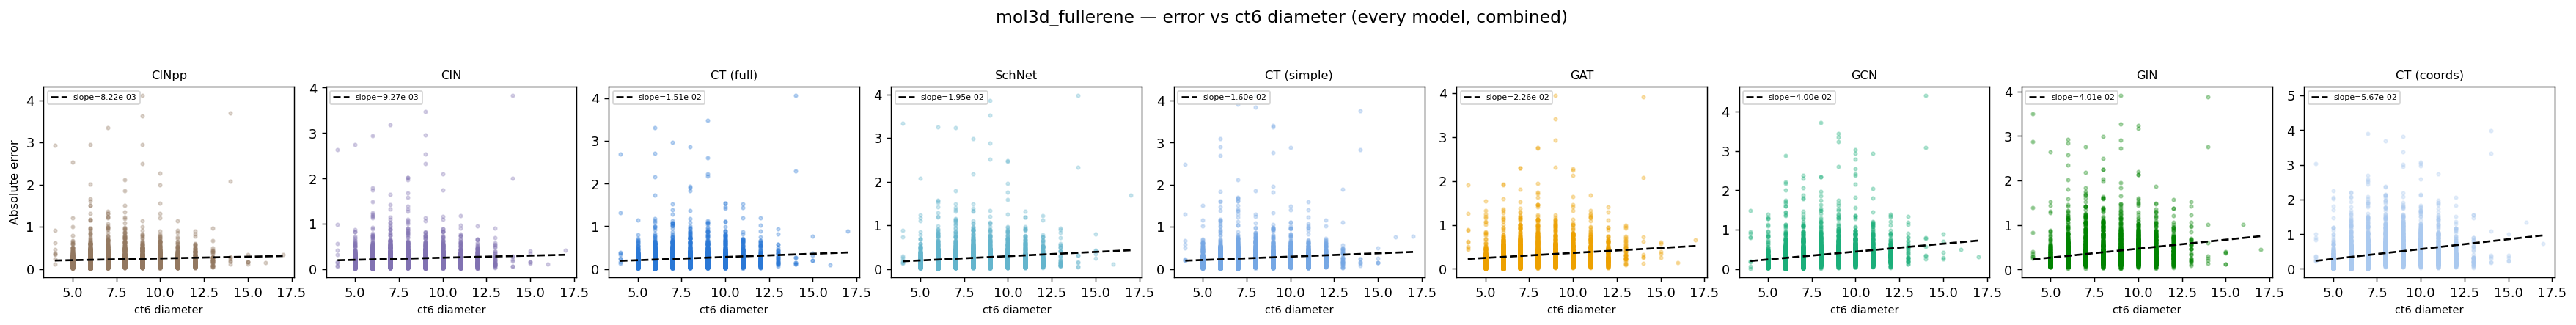

In [22]:
plot_err_vs_diameter('ct6')

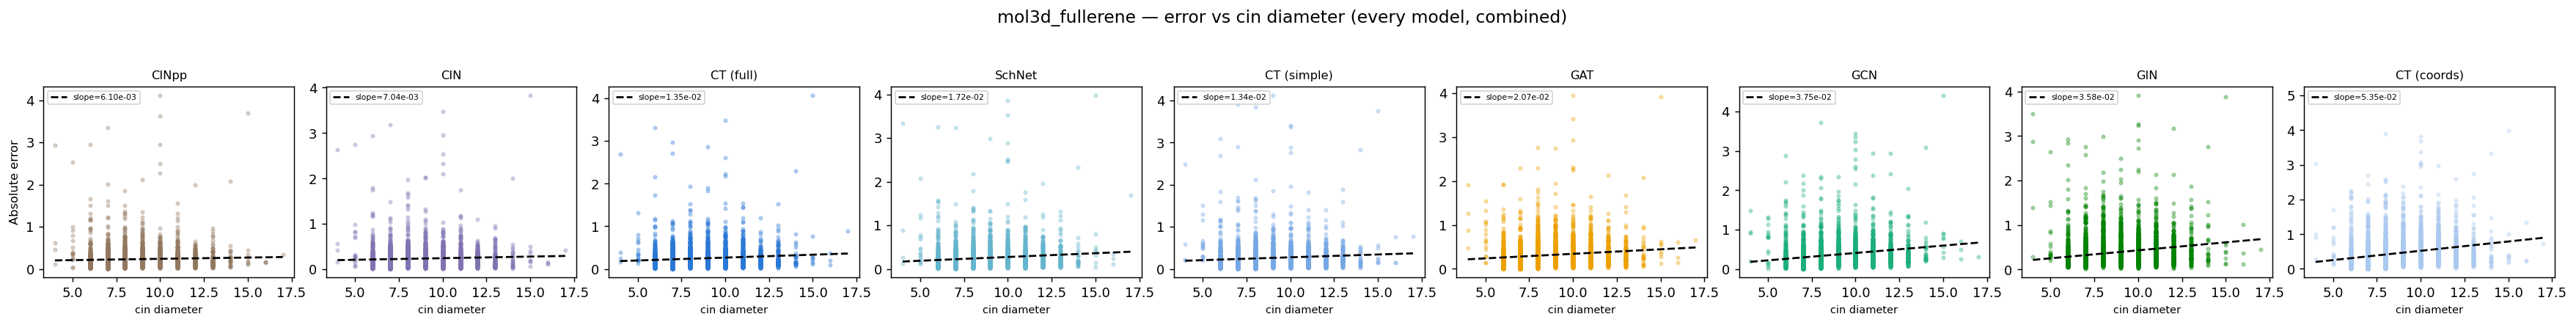

In [23]:
plot_err_vs_diameter('cin')

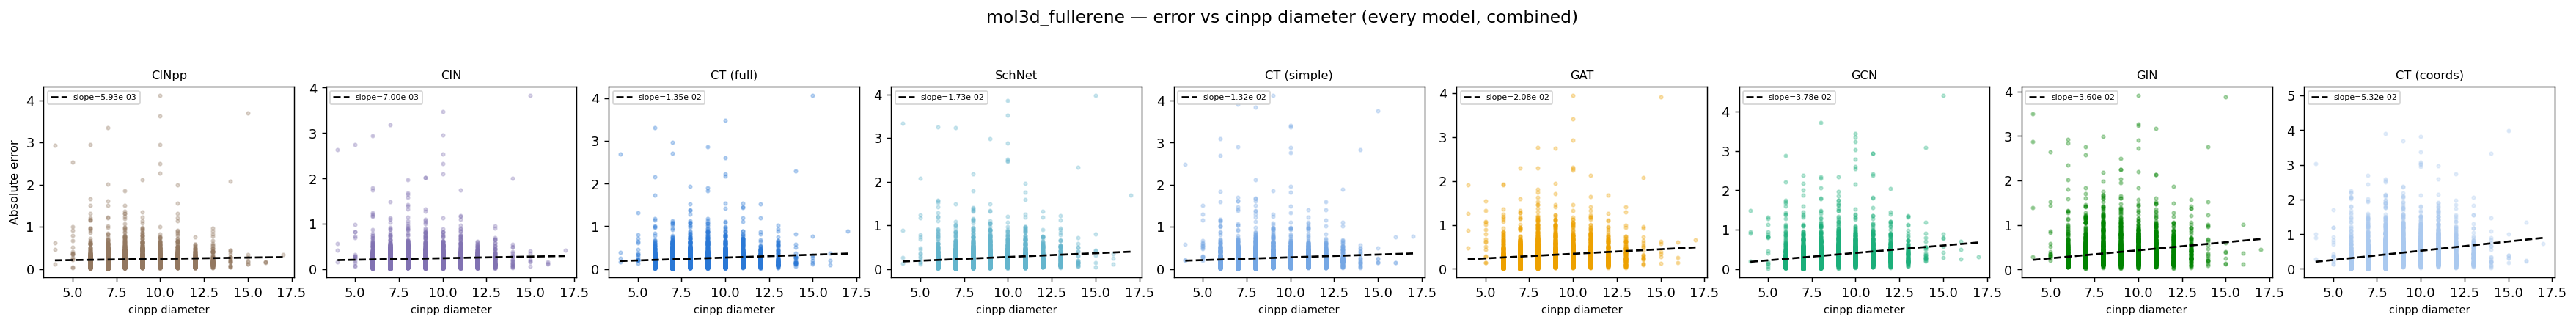

In [24]:
plot_err_vs_diameter('cinpp')

## GNN vs. Other Architectures — Diameter by Outcome

For every non-GNN model (CT-coords/simple/full, CIN, CINpp — **SchNet excluded**, see intro), split test molecules into two sets: **gnn_beats** (at least one of GCN/GAT/GIN has strictly lower error than this model on that molecule) vs. **model_beats** (this model's error was ≤ every GNN's there — it held its own). Same construction as `analyze_commute_time.ipynb`'s GNN-comparison sections (identical `err_maps`, so identical sets). mol3d + fullerene pooled.

Four panels per model: **plain graph diameter** (atom) by outcome, **this model's own** Hasse diameter (`ct6` for CT variants, `cin` for CIN, `cinpp` for CINpp) by outcome, the **difference** `hasse - atom` diameter by outcome (always ≤ 0, since Hasse is atom-restricted), and the **ratio** `hasse/atom` diameter by outcome. Same 3-color scheme: gray = overlap, red = `gnn_beats`-only excess, blue = `model_beats`-only excess (density-normalized histograms, stacked).

In [25]:
GNN_MODELS = [lbl for lbl in model_labels if lbl in ('GCN', 'GAT', 'GIN')]
NON_GNN_MODELS = [lbl for lbl in model_labels if lbl not in GNN_MODELS and lbl != 'SchNet']
# SchNet excluded: it has no ct6/cin/cinpp-analogous graph type of its own (see intro).

def model_prefix(label):
    """Which graph type this model's own diameter comes from."""
    if label.startswith('CT'):
        return 'ct6'
    if label.startswith('CINpp'):
        return 'cinpp'
    if label.startswith('CIN'):
        return 'cin'
    raise ValueError(f'no prefix mapping for {label}')

def build_gnn_beats_set(model_label):
    """molecule (source, index) keys present in model_label's AND every GNN's
    err_maps. gnn_beats = keys where the best GNN's error is strictly lower
    than model_label's error there; model_beats = the rest of the common set
    (model_label's error was <= every GNN's, i.e. it held its own)."""
    common = set(err_maps[model_label])
    for g in GNN_MODELS:
        common &= set(err_maps[g])
    beats = {k for k in common
             if min(err_maps[g][k] for g in GNN_MODELS) < err_maps[model_label][k]}
    return beats, common - beats

gnn_beats_sets = {m: build_gnn_beats_set(m) for m in NON_GNN_MODELS}
for m in NON_GNN_MODELS:
    gnn_beats, model_beats = gnn_beats_sets[m]
    print(f'{m:14s}  gnn_beats={len(gnn_beats)}  model_beats={len(model_beats)}')

CINpp           gnn_beats=1734  model_beats=1686
CIN             gnn_beats=1782  model_beats=1638
CT (full)       gnn_beats=1877  model_beats=1543
CT (simple)     gnn_beats=1872  model_beats=1548
CT (coords)     gnn_beats=2418  model_beats=1002


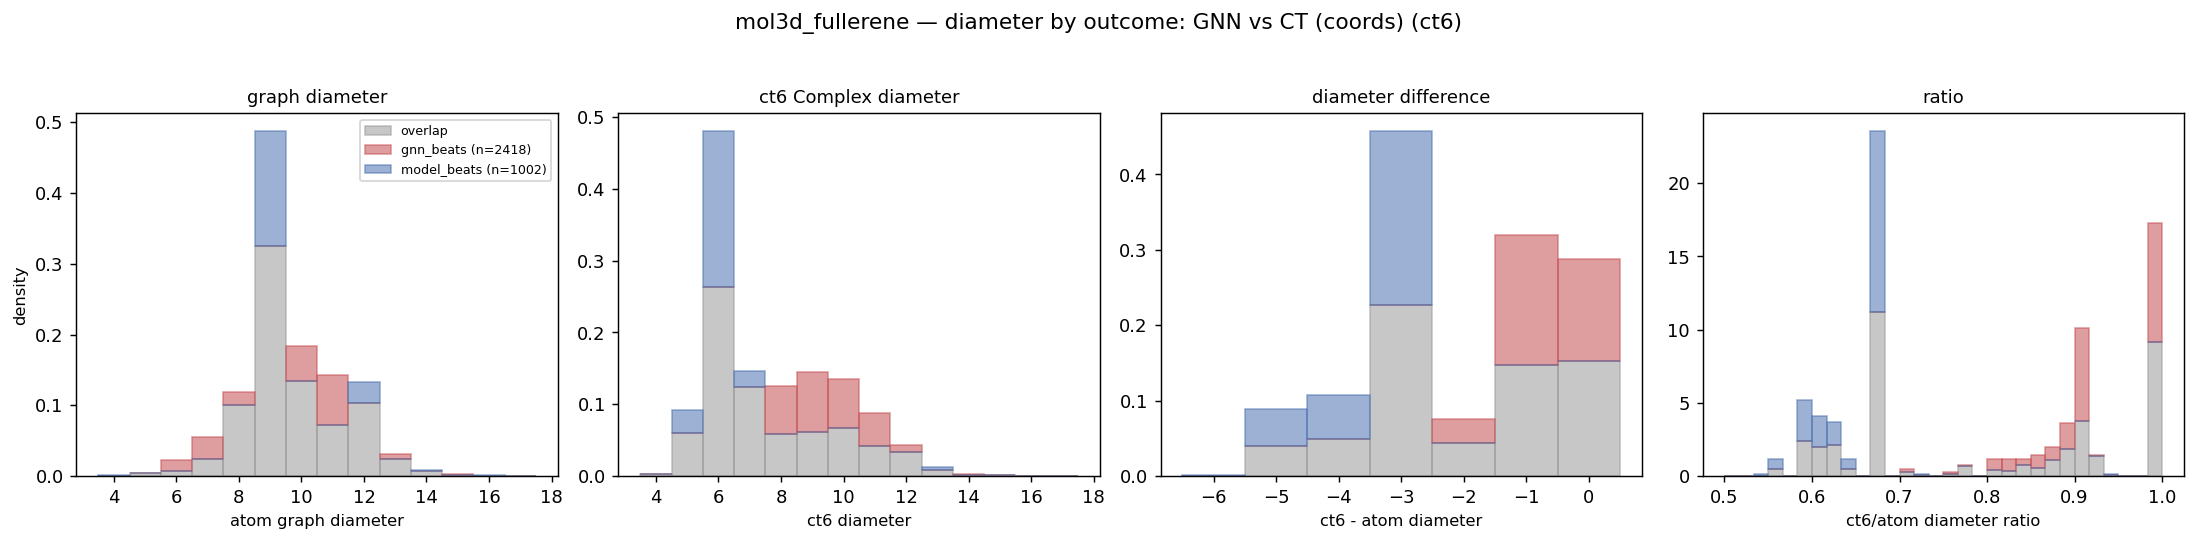

In [31]:
OUTCOME_COLOR = {'gnn_beats': '#C44E52', 'model_beats': '#4C72B0'}
OVERLAP_COLOR = '#999999'

def _diam_vals(prefix, keys):
    vals = [get_diameter(*k, prefix) for k in keys]
    vals = [v for v in vals if v is not None]
    return np.array(vals, dtype=float)

def _diff_vals(prefix, keys):
    vals = []
    for k in keys:
        n = get_diameter(*k, prefix)
        d = get_diameter(*k, 'atom')
        if n is None or d is None:
            continue
        vals.append(n - d)
    return np.array(vals, dtype=float)

def _ratio_vals(prefix, keys):
    vals = []
    for k in keys:
        n = get_diameter(*k, prefix)
        d = get_diameter(*k, 'atom')
        if n is None or d is None or d == 0:
            continue
        vals.append(n / d)
    return np.array(vals, dtype=float)

def _stacked_hist(ax, vals_a, vals_b, label_a, label_b, color_a, color_b, bins=30, integer=False):
    """Overlap (gray) as base, per-bin excess of whichever group is taller
    stacked on top in that group's own color. Bars are translucent with a
    solid-color outline so overlapping regions stay readable. integer=True
    uses one bin per integer value so bars touch with no gaps except where a
    diameter value truly has zero count -- used for the 3 integer-valued
    panels (diameter has no fractional values); the ratio panel stays
    continuous (default 30 bins)."""
    all_vals = np.concatenate([vals_a, vals_b])
    if integer:
        lo, hi = int(np.floor(all_vals.min())), int(np.ceil(all_vals.max()))
        edges = np.arange(lo - 0.5, hi + 1.5, 1.0)
    else:
        edges = np.histogram_bin_edges(all_vals, bins=bins)
    h_a, _ = np.histogram(vals_a, bins=edges, density=True)
    h_b, _ = np.histogram(vals_b, bins=edges, density=True)
    overlap = np.minimum(h_a, h_b)
    excess_a = h_a - overlap
    excess_b = h_b - overlap
    width = edges[1] - edges[0]
    centers = (edges[:-1] + edges[1:]) / 2
    ax.bar(centers, overlap, width=width, color=OVERLAP_COLOR, alpha=0.55,
           edgecolor=OVERLAP_COLOR, linewidth=0.9, label='overlap')
    ax.bar(centers, excess_a, width=width, bottom=overlap, color=color_a, alpha=0.55,
           edgecolor=color_a, linewidth=0.9, label=f'{label_a} (n={len(vals_a)})')
    ax.bar(centers, excess_b, width=width, bottom=overlap, color=color_b, alpha=0.55,
           edgecolor=color_b, linewidth=0.9, label=f'{label_b} (n={len(vals_b)})')

def plot_diameter_hist_by_outcome(model_label):
    p = model_prefix(model_label)
    gnn_beats, model_beats = gnn_beats_sets[model_label]
    fig, axes = plt.subplots(1, 4, figsize=(17, 4))

    ax = axes[0]
    _stacked_hist(ax, _diam_vals('atom', gnn_beats), _diam_vals('atom', model_beats),
                  'gnn_beats', 'model_beats', OUTCOME_COLOR['gnn_beats'], OUTCOME_COLOR['model_beats'],
                  integer=True)
    ax.set_xlabel('atom graph diameter', fontsize=9)
    ax.set_ylabel('density', fontsize=9)
    ax.set_title('graph diameter', fontsize=10)
    ax.legend(fontsize=7)

    ax = axes[1]
    _stacked_hist(ax, _diam_vals(p, gnn_beats), _diam_vals(p, model_beats),
                  'gnn_beats', 'model_beats', OUTCOME_COLOR['gnn_beats'], OUTCOME_COLOR['model_beats'],
                  integer=True)
    ax.set_xlabel(f'{p} diameter', fontsize=9)
    ax.set_title(f'{p} Complex diameter', fontsize=10)

    ax = axes[2]
    _stacked_hist(ax, _diff_vals(p, gnn_beats), _diff_vals(p, model_beats),
                  'gnn_beats', 'model_beats', OUTCOME_COLOR['gnn_beats'], OUTCOME_COLOR['model_beats'],
                  integer=True)
    ax.set_xlabel(f'{p} - atom diameter', fontsize=9)
    ax.set_title('diameter difference', fontsize=10)

    ax = axes[3]
    _stacked_hist(ax, _ratio_vals(p, gnn_beats), _ratio_vals(p, model_beats),
                  'gnn_beats', 'model_beats', OUTCOME_COLOR['gnn_beats'], OUTCOME_COLOR['model_beats'])
    ax.set_xlabel(f'{p}/atom diameter ratio', fontsize=9)
    ax.set_title('ratio', fontsize=10)

    plt.suptitle(f'mol3d_fullerene — diameter by outcome: GNN vs {model_label} ({p})', fontsize=12, y=1.03)
    plt.tight_layout()
    plt.show()

plot_diameter_hist_by_outcome('CT (coords)')

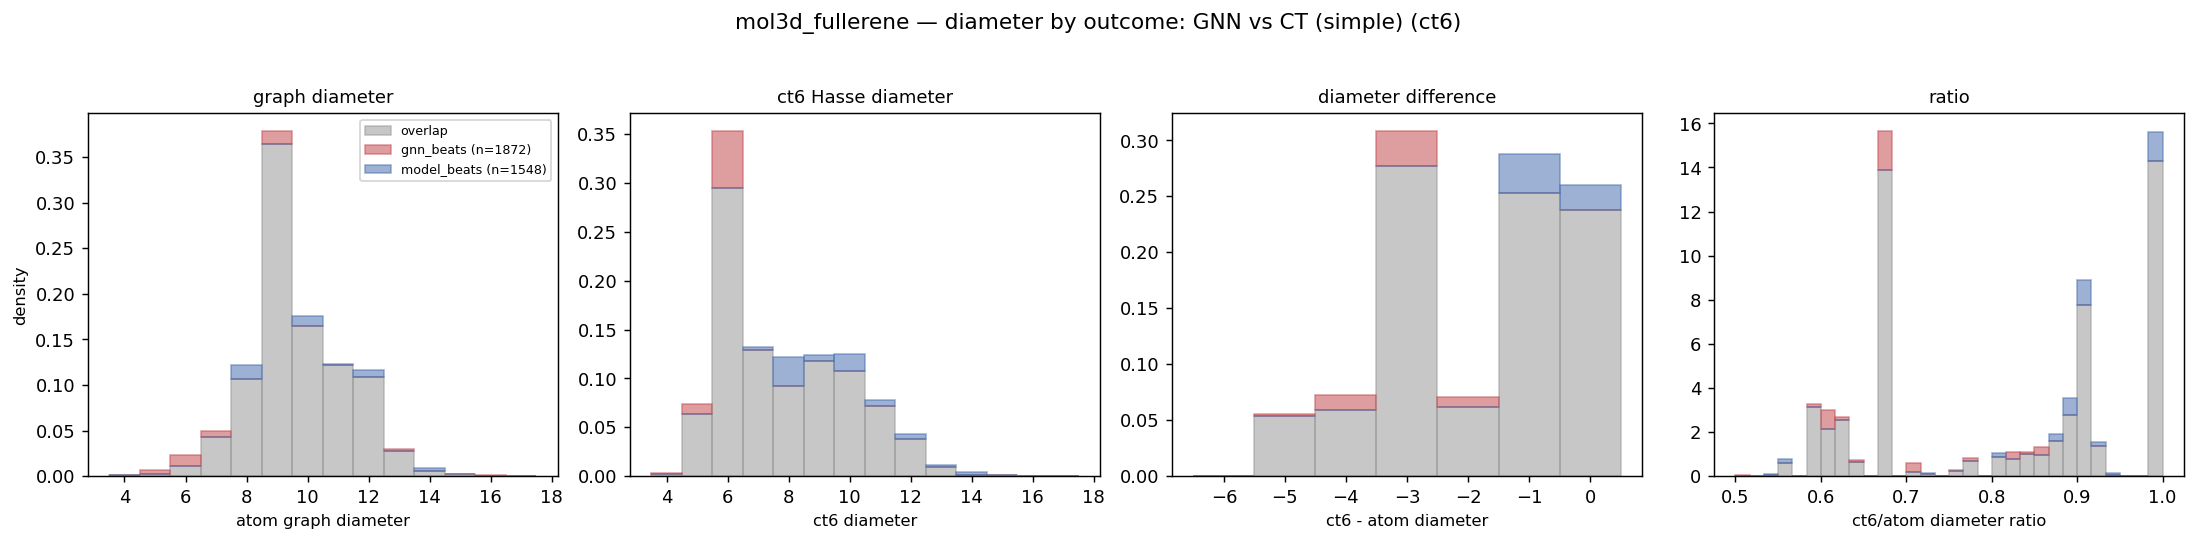

In [27]:
plot_diameter_hist_by_outcome('CT (simple)')

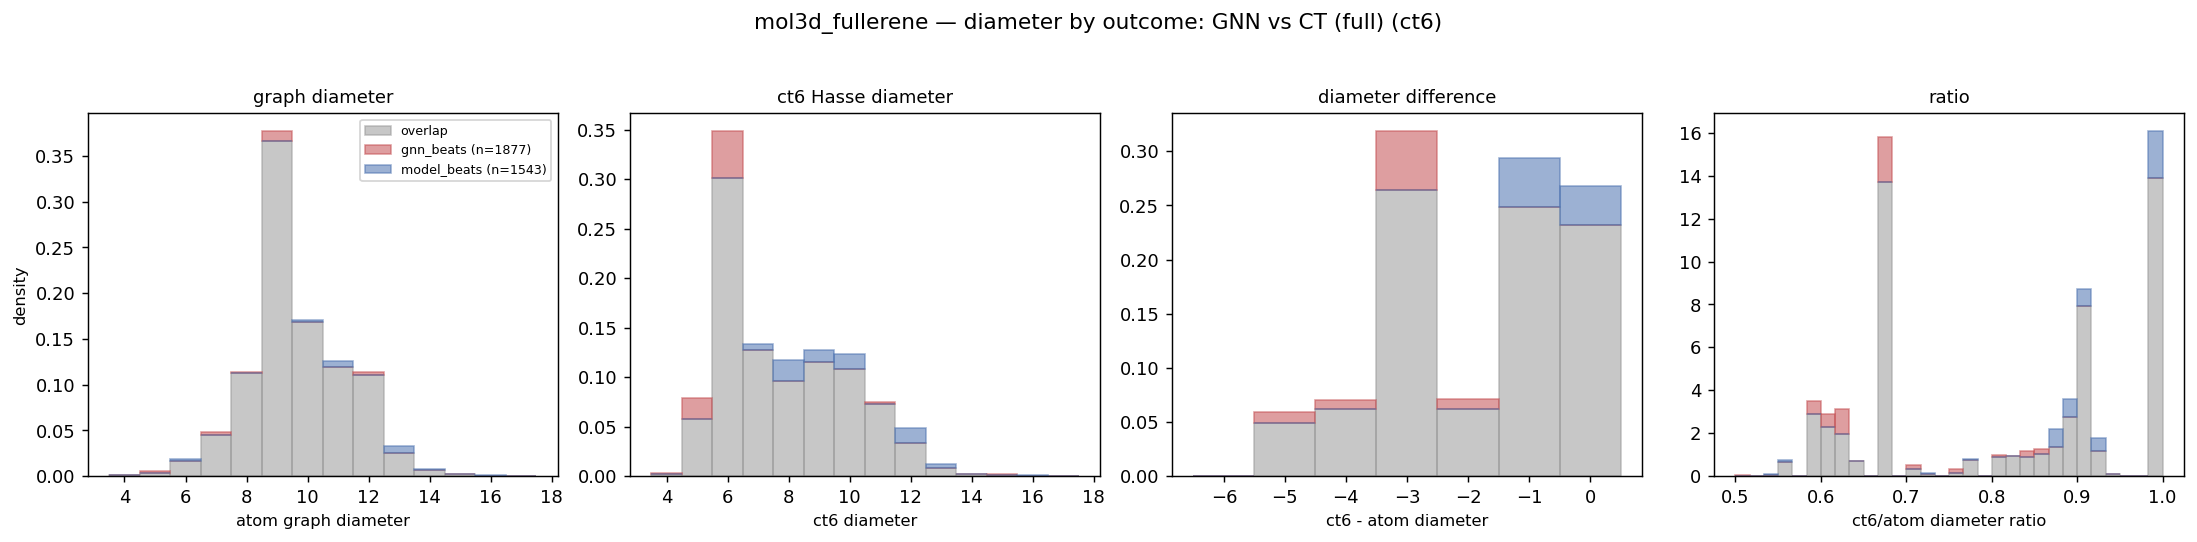

In [28]:
plot_diameter_hist_by_outcome('CT (full)')

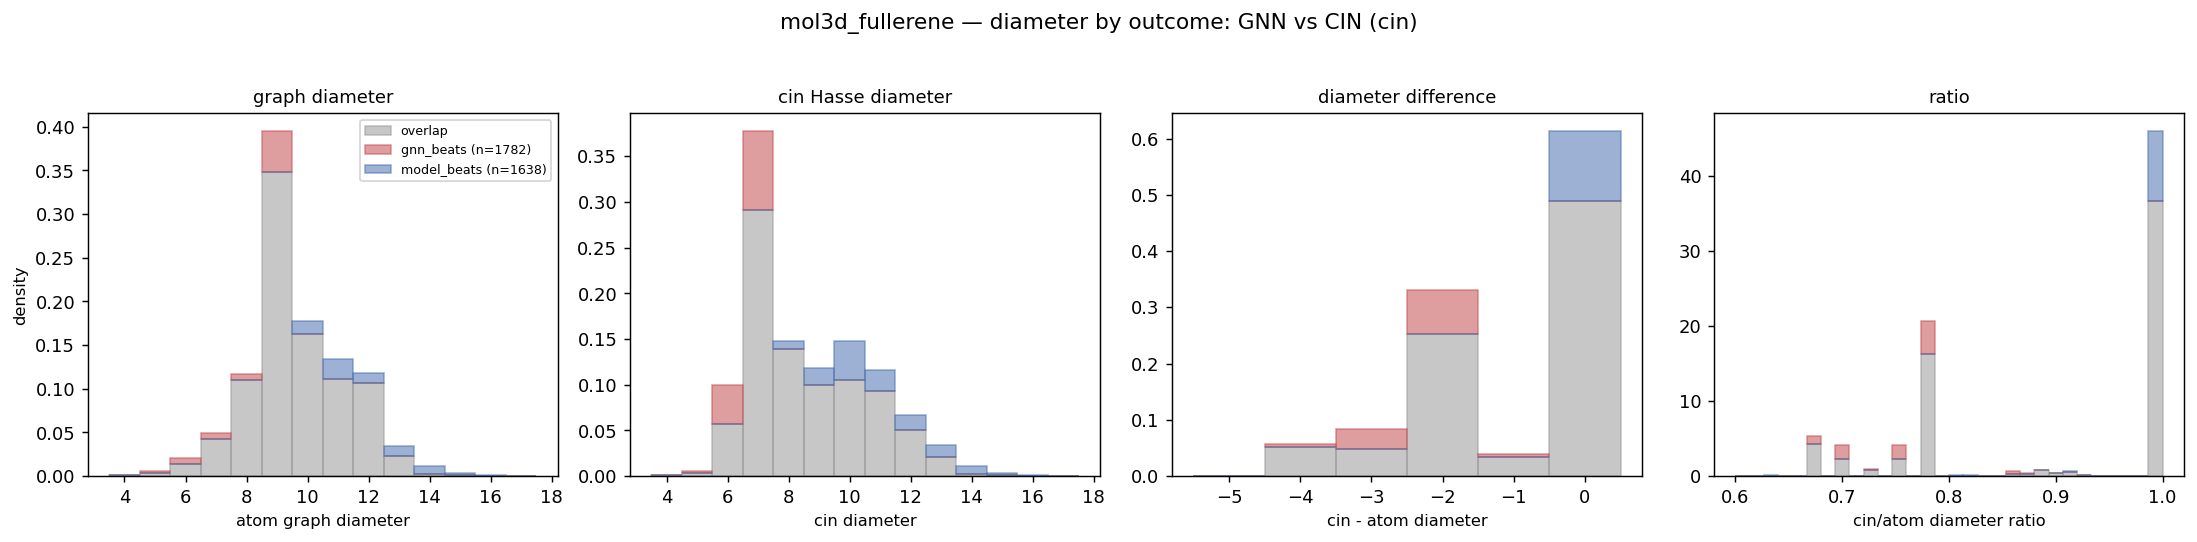

In [29]:
plot_diameter_hist_by_outcome('CIN')

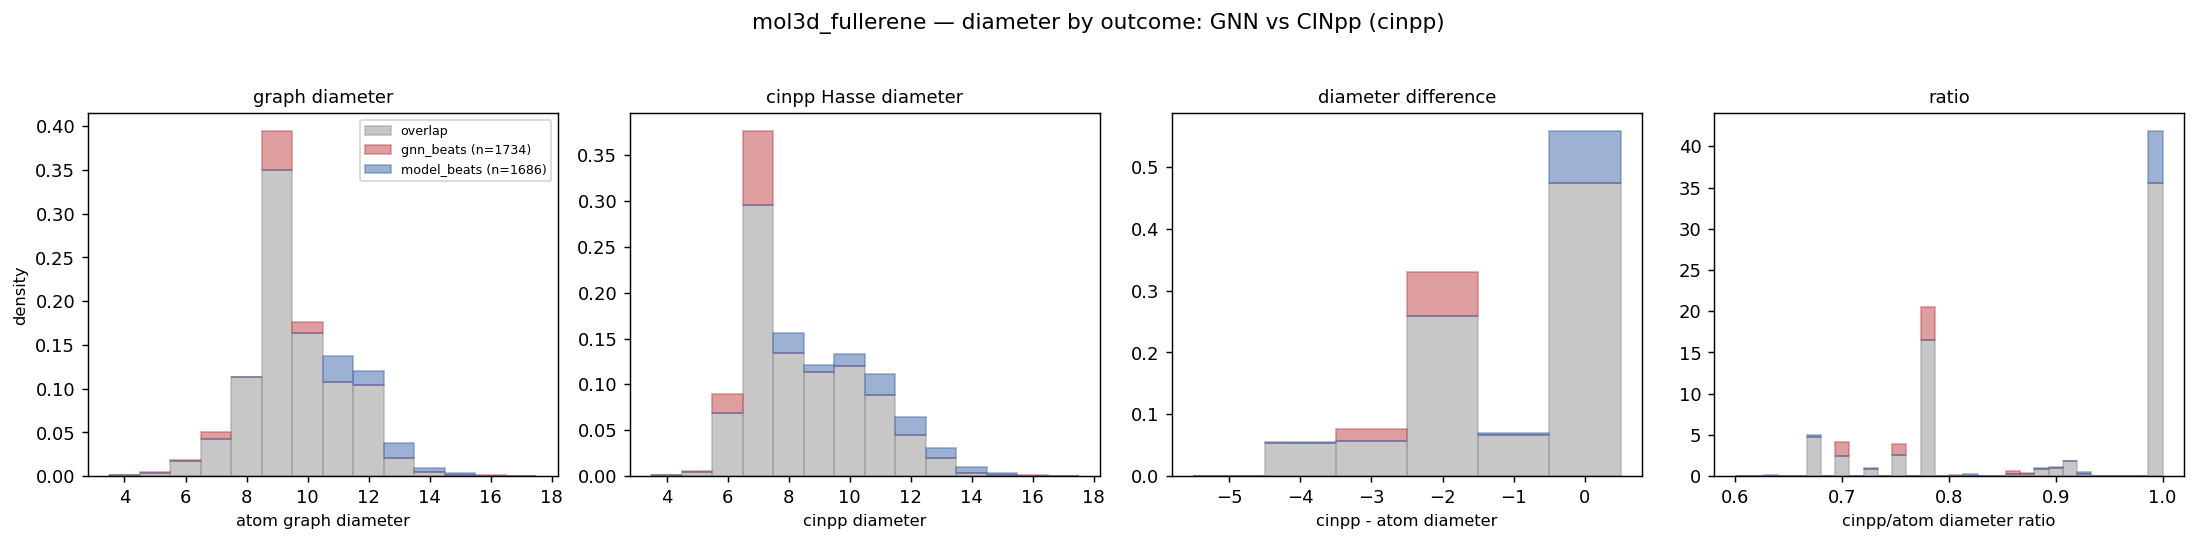

In [30]:
plot_diameter_hist_by_outcome('CINpp')